In [168]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('House_Prices.csv')

In [169]:
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1461.0,20.0,RH,80.0,11622.0,Pave,NaN,Reg,Lvl,AllPub,...,0.0,NaN,MnPrv,NaN,0.0,6.0,2010.0,WD,Normal,208500
1,1462.0,20.0,RL,81.0,14267.0,Pave,NaN,IR1,Lvl,AllPub,...,0.0,NaN,NaN,Gar2,12500.0,6.0,2010.0,WD,Normal,181500
2,1463.0,60.0,RL,74.0,13830.0,Pave,NaN,IR1,Lvl,AllPub,...,0.0,NaN,MnPrv,NaN,0.0,3.0,2010.0,WD,Normal,223500
3,1464.0,60.0,RL,78.0,9978.0,Pave,NaN,IR1,Lvl,AllPub,...,0.0,NaN,NaN,NaN,0.0,6.0,2010.0,WD,Normal,140000
4,1465.0,120.0,RL,43.0,5005.0,Pave,NaN,IR1,HLS,AllPub,...,0.0,NaN,NaN,NaN,0.0,1.0,2010.0,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,2916.0,160.0,RM,21.0,1894.0,Pave,NaN,Reg,Lvl,AllPub,...,0.0,NaN,NaN,NaN,0.0,4.0,2006.0,WD,Abnorml,175000
1456,2917.0,20.0,RL,160.0,20000.0,Pave,NaN,Reg,Lvl,AllPub,...,0.0,NaN,NaN,NaN,0.0,9.0,2006.0,WD,Abnorml,210000
1457,2918.0,85.0,RL,62.0,10441.0,Pave,NaN,Reg,Lvl,AllPub,...,0.0,NaN,MnPrv,Shed,700.0,7.0,2006.0,WD,Normal,266500
1458,2919.0,60.0,RL,74.0,9627.0,Pave,NaN,Reg,Lvl,AllPub,...,0.0,NaN,NaN,NaN,0.0,11.0,2006.0,WD,Normal,142125


In [170]:
df.shape

(1460, 81)

In [171]:
df.size

118260

In [172]:
# Create new features based on housing domain knowledge
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['TotalBath'] = df['FullBath'] + (0.5 * df['HalfBath']) + df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath'])
df['HasPool'] = df['PoolArea'].apply(lambda x: 1 if x > 0 else 0)

In [173]:
print(df[['TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'TotalSF', 'YearBuilt', 'YrSold', 'HouseAge', 'TotalBath', 'HasPool']].head())

   TotalBsmtSF  1stFlrSF  2ndFlrSF  TotalSF  YearBuilt  YrSold  HouseAge  \
0        882.0     896.0       0.0   1778.0     1961.0  2010.0      49.0   
1       1329.0    1329.0       0.0   2658.0     1958.0  2010.0      52.0   
2        928.0     928.0     701.0   2557.0     1997.0  2010.0      13.0   
3        926.0     926.0     678.0   2530.0     1998.0  2010.0      12.0   
4       1280.0    1280.0       0.0   2560.0     1992.0  2010.0      18.0   

   TotalBath  HasPool  
0        1.0        0  
1        1.5        0  
2        2.5        0  
3        2.5        0  
4        2.0        0  


In [174]:
df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalSF,HouseAge,TotalBath,HasPool
0,1461.0,20.0,RH,80.0,11622.0,Pave,NaN,Reg,Lvl,AllPub,...,0.0,6.0,2010.0,WD,Normal,208500,1778.0,49.0,1.0,0
1,1462.0,20.0,RL,81.0,14267.0,Pave,NaN,IR1,Lvl,AllPub,...,12500.0,6.0,2010.0,WD,Normal,181500,2658.0,52.0,1.5,0
2,1463.0,60.0,RL,74.0,13830.0,Pave,NaN,IR1,Lvl,AllPub,...,0.0,3.0,2010.0,WD,Normal,223500,2557.0,13.0,2.5,0
3,1464.0,60.0,RL,78.0,9978.0,Pave,NaN,IR1,Lvl,AllPub,...,0.0,6.0,2010.0,WD,Normal,140000,2530.0,12.0,2.5,0
4,1465.0,120.0,RL,43.0,5005.0,Pave,NaN,IR1,HLS,AllPub,...,0.0,1.0,2010.0,WD,Normal,250000,2560.0,18.0,2.0,0
5,1466.0,60.0,RL,75.0,10000.0,Pave,NaN,IR1,Lvl,AllPub,...,0.0,4.0,2010.0,WD,Normal,143000,2418.0,17.0,2.5,0
6,1467.0,20.0,RL,NaN,7980.0,Pave,NaN,IR1,Lvl,AllPub,...,500.0,3.0,2010.0,WD,Normal,307000,2355.0,18.0,3.0,0
7,1468.0,60.0,RL,63.0,8402.0,Pave,NaN,IR1,Lvl,AllPub,...,0.0,5.0,2010.0,WD,Normal,200000,2254.0,12.0,2.5,0
8,1469.0,20.0,RL,85.0,10176.0,Pave,NaN,Reg,Lvl,AllPub,...,0.0,2.0,2010.0,WD,Normal,129900,2641.0,20.0,2.5,0
9,1470.0,20.0,RL,70.0,8400.0,Pave,NaN,Reg,Lvl,AllPub,...,0.0,4.0,2010.0,WD,Normal,118000,1764.0,40.0,2.0,0


In [175]:
# Fill missing values for the new features to ensure downstream compatibility
df['TotalSF'] = df['TotalSF'].fillna(df['TotalSF'].median())
df['TotalBath'] = df['TotalBath'].fillna(df['TotalBath'].median())
df['OverallQual'] = df['OverallQual'].fillna(df['OverallQual'].median())

In [176]:
df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalSF,HouseAge,TotalBath,HasPool
0,1461.0,20.0,RH,80.0,11622.0,Pave,NaN,Reg,Lvl,AllPub,...,0.0,6.0,2010.0,WD,Normal,208500,1778.0,49.0,1.0,0
1,1462.0,20.0,RL,81.0,14267.0,Pave,NaN,IR1,Lvl,AllPub,...,12500.0,6.0,2010.0,WD,Normal,181500,2658.0,52.0,1.5,0
2,1463.0,60.0,RL,74.0,13830.0,Pave,NaN,IR1,Lvl,AllPub,...,0.0,3.0,2010.0,WD,Normal,223500,2557.0,13.0,2.5,0
3,1464.0,60.0,RL,78.0,9978.0,Pave,NaN,IR1,Lvl,AllPub,...,0.0,6.0,2010.0,WD,Normal,140000,2530.0,12.0,2.5,0
4,1465.0,120.0,RL,43.0,5005.0,Pave,NaN,IR1,HLS,AllPub,...,0.0,1.0,2010.0,WD,Normal,250000,2560.0,18.0,2.0,0
5,1466.0,60.0,RL,75.0,10000.0,Pave,NaN,IR1,Lvl,AllPub,...,0.0,4.0,2010.0,WD,Normal,143000,2418.0,17.0,2.5,0
6,1467.0,20.0,RL,NaN,7980.0,Pave,NaN,IR1,Lvl,AllPub,...,500.0,3.0,2010.0,WD,Normal,307000,2355.0,18.0,3.0,0
7,1468.0,60.0,RL,63.0,8402.0,Pave,NaN,IR1,Lvl,AllPub,...,0.0,5.0,2010.0,WD,Normal,200000,2254.0,12.0,2.5,0
8,1469.0,20.0,RL,85.0,10176.0,Pave,NaN,Reg,Lvl,AllPub,...,0.0,2.0,2010.0,WD,Normal,129900,2641.0,20.0,2.5,0
9,1470.0,20.0,RL,70.0,8400.0,Pave,NaN,Reg,Lvl,AllPub,...,0.0,4.0,2010.0,WD,Normal,118000,1764.0,40.0,2.0,0


In [177]:
from sklearn.preprocessing import PolynomialFeatures

# Generate degree 2 interaction terms for highly correlated features
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_feats = poly.fit_transform(df[['TotalSF', 'OverallQual']])
poly_cols = poly.get_feature_names_out(['TotalSF', 'OverallQual'])

# Append polynomial features back to the main dataframe
df_poly = pd.DataFrame(poly_feats, columns=poly_cols)
df = pd.concat([df, df_poly.drop(columns=['TotalSF', 'OverallQual'])], axis=1)

print("After Adding Polynomial Features")
print(df[['TotalSF', 'OverallQual', 'TotalSF^2', 'TotalSF OverallQual', 'OverallQual^2']].head())

After Adding Polynomial Features
   TotalSF  OverallQual  TotalSF^2  TotalSF OverallQual  OverallQual^2
0   1778.0          5.0  3161284.0               8890.0           25.0
1   2658.0          6.0  7064964.0              15948.0           36.0
2   2557.0          5.0  6538249.0              12785.0           25.0
3   2530.0          6.0  6400900.0              15180.0           36.0
4   2560.0          8.0  6553600.0              20480.0           64.0


In [178]:
# Discretize the continuous 'YearBuilt' variable into distinct historical eras
bins = [0, 1950, 1980, 2000, 2025]
labels = ['Pre-1950', '1950-1980', '1980-2000', '2000+']
df['YearBuilt_Binned'] = pd.cut(df['YearBuilt'], bins=bins, labels=labels)

print("\n--- After Binning YearBuilt ---")
print(df[['YearBuilt', 'YearBuilt_Binned']].head(10))


--- After Binning YearBuilt ---
   YearBuilt YearBuilt_Binned
0     1961.0        1950-1980
1     1958.0        1950-1980
2     1997.0        1980-2000
3     1998.0        1980-2000
4     1992.0        1980-2000
5     1993.0        1980-2000
6     1992.0        1980-2000
7     1998.0        1980-2000
8     1990.0        1980-2000
9     1970.0        1950-1980


In [179]:
# Replace categorical neighborhood names with their historical average sale price
neighborhood_means = df.groupby('Neighborhood')['SalePrice'].mean().to_dict()
df['Neighborhood_Target_Enc'] = df['Neighborhood'].map(neighborhood_means)

print("After Target Encoding Neighborhood")
print(df[['Neighborhood', 'SalePrice', 'Neighborhood_Target_Enc']].head())

After Target Encoding Neighborhood
  Neighborhood  SalePrice  Neighborhood_Target_Enc
0        NAmes     208500            181064.000000
1        NAmes     181500            181064.000000
2      Gilbert     223500            196961.790698
3      Gilbert     140000            196961.790698
4      StoneBr     250000            217797.461538


In [180]:
from sklearn.feature_selection import mutual_info_regression

# Define the engineered features to evaluate
features = [
    'TotalSF', 'OverallQual', 'HouseAge', 'TotalBath', 'HasPool',
    'TotalSF^2', 'TotalSF OverallQual', 'OverallQual^2', 'Neighborhood_Target_Enc'
]

In [181]:
# Drop rows missing the target variable for accurate selection
df_fs = df.dropna(subset=features + ['SalePrice']).copy()
X = df_fs[features]
y = df_fs['SalePrice']

In [182]:
# Mutual Information
mi_scores = mutual_info_regression(X, y)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
print("Top Features (Mutual Information):\n", mi_series.head())

Top Features (Mutual Information):
 TotalBath                  0.041348
HouseAge                   0.029643
Neighborhood_Target_Enc    0.016806
TotalSF OverallQual        0.009214
OverallQual                0.009086
dtype: float64


In [183]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# Recursive Feature Elimination (RFE)
rfe = RFE(estimator=LinearRegression(), n_features_to_select=5)
rfe.fit(X, y)
rfe_selected = X.columns[rfe.support_].tolist()
print("Selected via RFE:", rfe_selected)

Selected via RFE: ['OverallQual', 'HouseAge', 'TotalBath', 'HasPool', 'OverallQual^2']


In [184]:
from sklearn.linear_model import Lasso

# L1 Regularization (Lasso)
lasso = Lasso(alpha=100.0, max_iter=10000)
lasso.fit(X, y)
l1_selected = X.columns[lasso.coef_ != 0].tolist()
print("Selected via L1 (Lasso):", l1_selected)

Selected via L1 (Lasso): ['TotalSF', 'OverallQual', 'HouseAge', 'TotalBath', 'TotalSF^2', 'TotalSF OverallQual', 'OverallQual^2', 'Neighborhood_Target_Enc']


/tmp/ipykernel_1063/704472313.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 1], data=df, x='YearBuilt_Binned', y='SalePrice', palette='Set2')
/tmp/ipykernel_1063/704472313.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 1], x=mi_series.values, y=mi_series.index, palette='viridis')


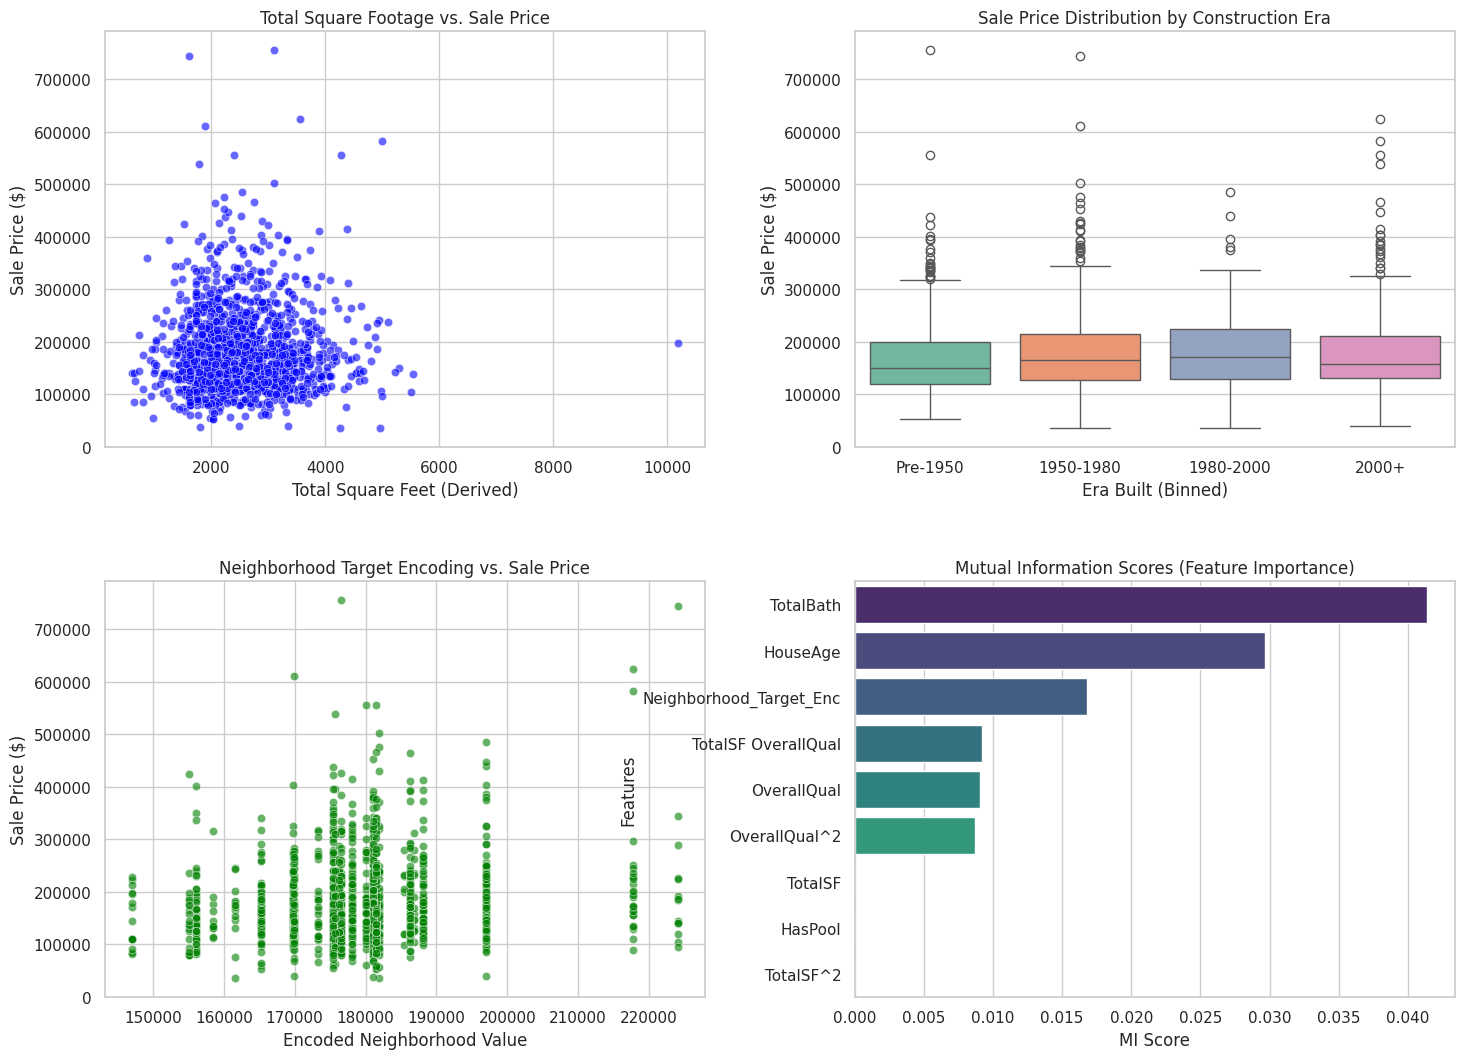

In [185]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style and figure canvas
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.tight_layout(pad=6.0)

# Domain Feature Plot
sns.scatterplot(ax=axes[0, 0], data=df, x='TotalSF', y='SalePrice', alpha=0.6, color='blue')
axes[0, 0].set_title('Total Square Footage vs. Sale Price')
axes[0, 0].set_xlabel('Total Square Feet (Derived)')
axes[0, 0].set_ylabel('Sale Price ($)')

# Binned Feature Plot
sns.boxplot(ax=axes[0, 1], data=df, x='YearBuilt_Binned', y='SalePrice', palette='Set2')
axes[0, 1].set_title('Sale Price Distribution by Construction Era')
axes[0, 1].set_xlabel('Era Built (Binned)')
axes[0, 1].set_ylabel('Sale Price ($)')

# Target Encoding Plot
sns.scatterplot(ax=axes[1, 0], data=df, x='Neighborhood_Target_Enc', y='SalePrice', alpha=0.6, color='green')
axes[1, 0].set_title('Neighborhood Target Encoding vs. Sale Price')
axes[1, 0].set_xlabel('Encoded Neighborhood Value')
axes[1, 0].set_ylabel('Sale Price ($)')

# Feature Selection Plot
sns.barplot(ax=axes[1, 1], x=mi_series.values, y=mi_series.index, palette='viridis')
axes[1, 1].set_title('Mutual Information Scores (Feature Importance)')
axes[1, 1].set_xlabel('MI Score')
axes[1, 1].set_ylabel('Features')

plt.show()